In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [4]:
df = df.drop_duplicates()

df = df.drop(columns=[
    'Campaign_ID',
    'Product_ID',
    'Customer_ID',
    'Flash_Sale_ID',
    'Bundle_ID',
    'Common_Keywords'
], errors='ignore')

df = df.dropna()

df.head()

,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Tier,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
0,41770.45,4946,73,15520.09,1.94,Premium,4,43,34,433.80,4
1,29900.93,570,510,30866.17,0.76,Premium,4,28,97,289.29,2
2,22367.45,3546,265,32585.62,1.41,Basic,9,51,160,462.87,4
3,29957.54,2573,781,95740.12,3.32,Premium,32,36,159,334.16,1
4,36277.19,818,79,81990.43,3.53,Standard,29,20,52,371.67,2


In [5]:
le = LabelEncoder()

df['Subscription_Tier'] = le.fit_transform(df['Subscription_Tier'])

df.head()

,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Tier,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
0,41770.45,4946,73,15520.09,1.94,1,4,43,34,433.80,4
1,29900.93,570,510,30866.17,0.76,1,4,28,97,289.29,2
2,22367.45,3546,265,32585.62,1.41,0,9,51,160,462.87,4
3,29957.54,2573,781,95740.12,3.32,1,32,36,159,334.16,1
4,36277.19,818,79,81990.43,3.53,2,29,20,52,371.67,2


In [6]:
X = df.drop(columns=['Revenue_Generated'])

y = df['Revenue_Generated']

X.head()

,Budget,Clicks,Conversions,ROI,Subscription_Tier,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
0,41770.45,4946,73,1.94,1,4,43,34,433.80,4
1,29900.93,570,510,0.76,1,4,28,97,289.29,2
2,22367.45,3546,265,1.41,0,9,51,160,462.87,4
3,29957.54,2573,781,3.32,1,32,36,159,334.16,1
4,36277.19,818,79,3.53,2,29,20,52,371.67,2


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 10)
(2000, 10)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [9]:
models = {

    'Linear Regression': LinearRegression(),

    'Decision Tree': DecisionTreeRegressor(random_state=42),

    'Random Forest': RandomForestRegressor(random_state=42),

    'XGBoost': XGBRegressor(random_state=42),

    'SVR': SVR()
}

results = []

for name, model in models.items():

    if name == 'SVR':

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R2']
)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,24756.218949,28601.119602,-0.003182
1,Decision Tree,32103.142430,39660.066718,-0.928949
2,Random Forest,25138.487290,29181.173018,-0.044286
3,XGBoost,26170.225273,30789.654385,-0.162582
4,SVR,24728.572268,28589.676983,-0.002380


In [10]:
results_df.to_csv('RQ2_Model_Comparison.csv', index=False)

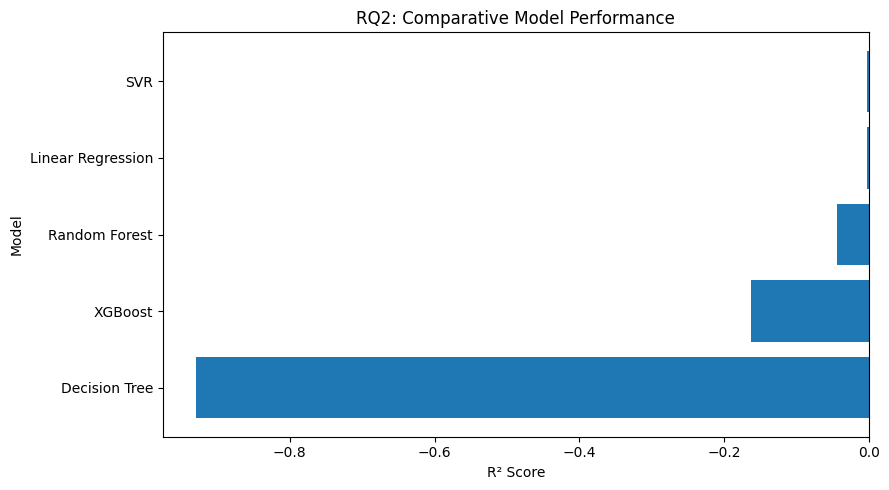

In [11]:
ranked_df = results_df.sort_values(
    by='R2',
    ascending=True
)

plt.figure(figsize=(9,5))

plt.barh(
    ranked_df['Model'],
    ranked_df['R2']
)

plt.xlabel('R² Score')

plt.ylabel('Model')

plt.title('RQ2: Comparative Model Performance')

plt.tight_layout()

plt.savefig('RQ2_Model_Comparison.pdf')

plt.show()

## Conclusion

Advanced ensemble learning models achieved stronger predictive performance compared to baseline regression models for revenue prediction.